# Recovery map from real RV data: GJ 724

In this notebook, we illustrate how to compute a recovery map from a real radial-velocity dataset using **RAVEX**.

We use the published RV measurements of **GJ 724** from **Gorrini et al. (2023)**, combining the **CARMENES VIS** and **HARPS** datasets. The goal is not to analyse the raw RVs directly, but to estimate the detectability of **additional planetary companions** once the known planet has been removed.

For this didactic example, we adopt a simple and transparent approach:

1. load the published RV data,
2. define the known planet using the orbital parameters reported in the paper,
3. subtract the Keplerian signal of the known planet,
4. account for instrument-dependent offsets and effective uncertainties,
5. compute the recovery map on the residual RVs.

This corresponds to an **approximate but physically informed** treatment of the real dataset. It does not reproduce the full published model exactly, because the best model in the paper also includes a Gaussian-process component. However, it provides a clean and practical workflow for users who want to compute recovery maps from real RV data in a controlled and reproducible way.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.time as t

from ravex import MultiPlanetSystem, plot_detectability_map

# Load the published RV dataset
df = pd.read_csv(
    "gj724rv.dat",
    sep=r"\s+",
    names=["BJD", "RV", "e_RV", "Inst"]
)

df["Inst"] = df["Inst"].str.strip()

# Quick overview of the dataset
print(df.head())
print()
print(df["Inst"].value_counts())
print()
print(df.groupby("Inst")["e_RV"].agg(["count", "mean", "median"]))

            BJD        RV      e_RV      Inst
0  2.457536e+06 -1.760123  2.276315  CARM-VIS
1  2.457564e+06  0.132083  2.015037  CARM-VIS
2  2.457574e+06 -0.714806  3.312262  CARM-VIS
3  2.457596e+06  3.199021  2.305209  CARM-VIS
4  2.457605e+06  0.978552  2.325194  CARM-VIS

Inst
CARM-VIS    83
HARPS       27
Name: count, dtype: int64

          count      mean    median
Inst                               
CARM-VIS     83  1.937788  1.768561
HARPS        27  1.495667  1.347000


In [2]:
# Stellar mass adopted from Gorrini et al. (2023)
mass_star = 0.5271 * u.solMass

# Sort the dataset by time
df = df.sort_values("BJD").reset_index(drop=True)

# Observed quantities
jd = df["BJD"].to_numpy(dtype=float)
rv = df["RV"].to_numpy(dtype=float)
rv_err_internal = df["e_RV"].to_numpy(dtype=float)
inst = df["Inst"].to_numpy()

# Basic consistency checks
print(f"Total number of RVs: {len(df)}")
print(f"Time span: {jd.max() - jd.min():.1f} days")
print()

for name in np.unique(inst):
    m = inst == name
    print(
        f"{name:10s}  N = {m.sum():3d}   "
        f"<e_RV> = {rv_err_internal[m].mean():.3f} m/s   "
        f"median(e_RV) = {np.median(rv_err_internal[m]):.3f} m/s"
    )

Total number of RVs: 110
Time span: 5247.5 days

CARM-VIS    N =  83   <e_RV> = 1.938 m/s   median(e_RV) = 1.769 m/s
HARPS       N =  27   <e_RV> = 1.496 m/s   median(e_RV) = 1.347 m/s


## Adopt the published solution for the known planet

We now define the parameters of the known planet **GJ 724 b** using the values reported in **Gorrini et al. (2023)**.

For this tutorial, we adopt:

- the published Keplerian parameters of the planet,
- the published instrument-dependent RV offsets,
- and the published instrument-dependent jitter terms.

These quantities will be used to construct an approximate residual time series after subtracting the known planetary signal.

In [3]:
# Published orbital solution for GJ 724 b from Gorrini et al. (2023)
P_b_days = 5.101284
t0_b_bjd = 2457509.766
K_b_mps = 7.48
e_b = 0.577
omega_b_deg = 33.2

# Published instrument-dependent offsets (gamma) from the best-fit model
gamma_by_inst = {
    "CARM-VIS": 0.79,    # m/s
    "HARPS": -0.80,  # m/s
}

# Published instrument-dependent jitter terms from the best-fit model
jitter_by_inst = {
    "CARM-VIS": 1.18,    # m/s
    "HARPS": 0.65,   # m/s
}

print("Adopted planet parameters:")
print(f"P_b     = {P_b_days:.6f} d")
print(f"t0_b    = {t0_b_bjd:.3f} BJD")
print(f"K_b     = {K_b_mps:.2f} m/s")
print(f"e_b     = {e_b:.3f}")
print(f"omega_b = {omega_b_deg:.1f} deg")
print()

print("Adopted instrument offsets:")
for k, v in gamma_by_inst.items():
    print(f"{k:5s}: gamma = {v:+.2f} m/s")
print()

print("Adopted instrument jitters:")
for k, v in jitter_by_inst.items():
    print(f"{k:5s}: jitter = {v:.2f} m/s")

Adopted planet parameters:
P_b     = 5.101284 d
t0_b    = 2457509.766 BJD
K_b     = 7.48 m/s
e_b     = 0.577
omega_b = 33.2 deg

Adopted instrument offsets:
CARM-VIS: gamma = +0.79 m/s
HARPS: gamma = -0.80 m/s

Adopted instrument jitters:
CARM-VIS: jitter = 1.18 m/s
HARPS: jitter = 0.65 m/s


## Build the Keplerian model of the known planet

We now construct a `MultiPlanetSystem` containing only the published planet **GJ 724 b**.

The purpose of this step is to evaluate the expected Keplerian RV signal of the known planet at the exact observing times of the real dataset. This gives us a model component that can later be subtracted from the measured RVs.

At this stage, we do **not** include any additional noise and we do **not** yet subtract the instrument offsets.

In [4]:
# Define the published planet GJ 724 b
planet_b = {
    "mass": 10.75 * u.earthMass,                 # minimum mass from the paper
    "time_periastron": t.Time(t0_b_bjd, format="jd", scale="utc"),
    "inclination": 90.0 * u.deg,                 # use edge-on so that mass = Msin(i)
    "argument_periapse": omega_b_deg * u.deg,
    "eccentricity": e_b,
    "orbital_period": P_b_days * u.day,
    "reference_velocity": 0.0 * u.m / u.s,
}

# Build a one-planet system
system_planet = MultiPlanetSystem(
    mass_main=mass_star,
    planets=[planet_b]
)

# Evaluate the Keplerian signal of the known planet at the observed times
jd_model, rv_planet_model, phases_model, phased_model, rv_by_planet = system_planet.get_rvs(
    jd,
    noise=0.0 * u.m / u.s,
    include_per_planet=True
)

rv_planet = rv_by_planet["p0"]

print(f"Model evaluated at {len(rv_planet)} observing times.")
print(f"Planet model RV rms: {np.std(rv_planet):.3f} m/s")
print(f"Planet model RV peak-to-peak: {rv_planet.max() - rv_planet.min():.3f} m/s")

Model evaluated at 110 observing times.
Planet model RV rms: 3.832 m/s
Planet model RV peak-to-peak: 14.828 m/s


## Construct the residual RV time series

We now build the residual time series that will be used for the recovery map.

For each RV point, we subtract:

- the published instrument-dependent RV offset,
- the Keplerian signal of the known planet.

We also define an effective per-point uncertainty by adding the published instrument-dependent jitter in quadrature to the internal RV error.

This produces an approximate residual dataset that is suitable for testing the detectability of additional companions.

In [5]:
# Instrument-dependent offsets and effective uncertainties
gamma_vec = np.array([gamma_by_inst[name] for name in inst], dtype=float)
jitter_vec = np.array([jitter_by_inst[name] for name in inst], dtype=float)

# Effective uncertainty per point: internal error + published jitter in quadrature
rv_err_eff = np.sqrt(rv_err_internal**2 + jitter_vec**2)

# Residual RVs after subtracting instrument offsets and the known planet
rv_residual = rv - gamma_vec - rv_planet

print("Residual time series created.")
print(f"Residual RV rms: {np.std(rv_residual):.3f} m/s")
print(f"Mean effective uncertainty: {np.mean(rv_err_eff):.3f} m/s")
print()

for name in np.unique(inst):
    m = inst == name
    print(
        f"{name:10s}  "
        f"N = {m.sum():3d}   "
        f"<sigma_eff> = {rv_err_eff[m].mean():.3f} m/s   "
        f"RMS(residuals) = {np.std(rv_residual[m]):.3f} m/s"
    )

Residual time series created.
Residual RV rms: 3.707 m/s
Mean effective uncertainty: 2.128 m/s

CARM-VIS    N =  83   <sigma_eff> = 2.288 m/s   RMS(residuals) = 3.827 m/s
HARPS       N =  27   <sigma_eff> = 1.636 m/s   RMS(residuals) = 3.297 m/s


## Inspect the residual RV time series

Before computing the recovery map, it is useful to inspect the dataset visually.

In the figure below, we compare:

- the observed RV measurements,
- the Keplerian model of the known planet,
- and the residual RVs after subtracting both the published instrument offsets and the known planetary signal.

The effective uncertainties shown for the residuals include the published instrument-dependent jitter terms added in quadrature to the internal RV errors.

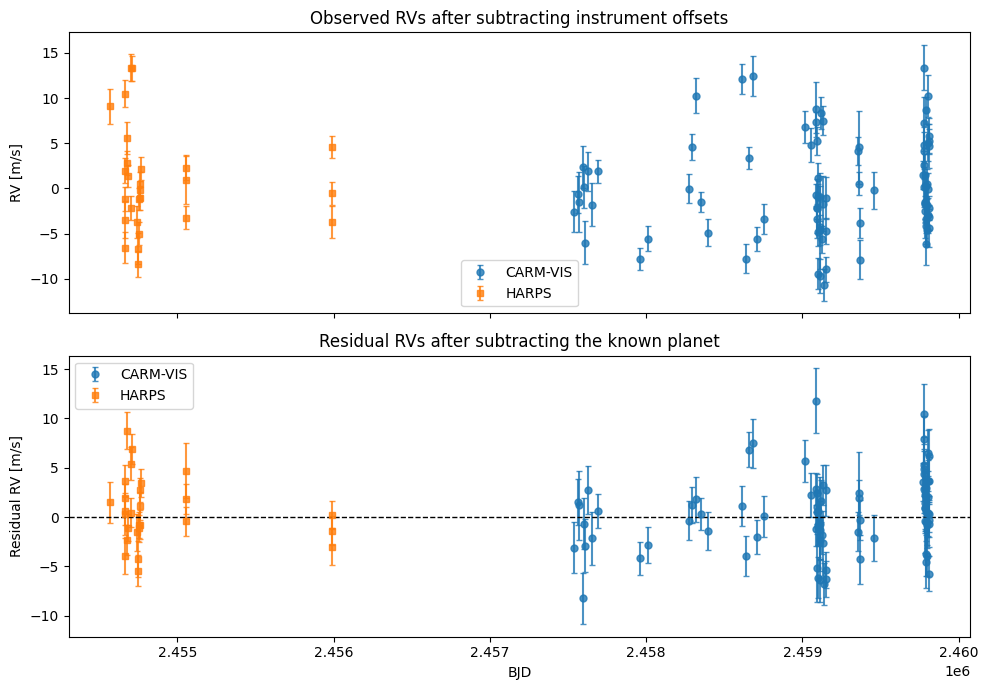

In [6]:
# Boolean masks by instrument
m_carm = inst == "CARM-VIS"
m_harps = inst == "HARPS"
# Dense time grid for visualization
jd_dense = np.linspace(jd.min(), jd.max(), 5000)

# Evaluate the published Keplerian model on a dense grid
_, _, _, _, rv_by_planet_dense = system_planet.get_rvs(
    jd_dense,
    noise=0.0 * u.m / u.s,
    include_per_planet=True
)
rv_planet_dense = rv_by_planet_dense["p0"]

# Offset-corrected observed RVs
rv_offset_corrected = rv - gamma_vec

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top panel: observed RVs after subtracting instrument offsets
axes[0].errorbar(
    jd[m_carm], rv_offset_corrected[m_carm],
    yerr=rv_err_internal[m_carm],
    fmt="o", ms=5, capsize=2,
    label="CARM-VIS",
    alpha=0.8
)

axes[0].errorbar(
    jd[m_harps], rv_offset_corrected[m_harps],
    yerr=rv_err_internal[m_harps],
    fmt="s", ms=5, capsize=2,
    label="HARPS",
    alpha=0.8
)

axes[0].set_ylabel("RV [m/s]")
axes[0].set_title("Observed RVs after subtracting instrument offsets")
axes[0].legend()

# Bottom panel: residuals
axes[1].errorbar(
    jd[m_carm], rv_residual[m_carm],
    yerr=rv_err_eff[m_carm],
    fmt="o", ms=5, capsize=2,
    label="CARM-VIS",
    alpha=0.8
)

axes[1].errorbar(
    jd[m_harps], rv_residual[m_harps],
    yerr=rv_err_eff[m_harps],
    fmt="s", ms=5, capsize=2,
    label="HARPS",
    alpha=0.8
)

axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("BJD")
axes[1].set_ylabel("Residual RV [m/s]")
axes[1].set_title("Residual RVs after subtracting the known planet")
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase-folded view of the known planet

A phase-folded representation is much more informative than the full time series when the orbital period is short compared to the total time span of the observations.

Here we fold the offset-corrected RVs using the published period of GJ 724 b and compare them with the published Keplerian model. This allows us to inspect the dominant planetary signal directly in phase space.

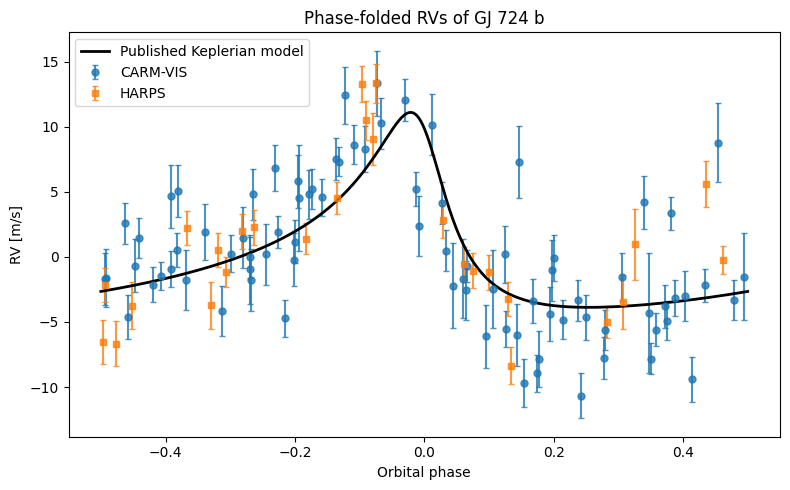

In [7]:
# Phase-fold the observed RVs using the published ephemeris
phase_obs = ((jd - t0_b_bjd) / P_b_days) % 1.0
phase_obs[phase_obs > 0.5] -= 1.0

# Sort for cleaner plotting
order = np.argsort(phase_obs)
phase_obs_sorted = phase_obs[order]
rv_offset_corrected_sorted = rv_offset_corrected[order]
rv_err_internal_sorted = rv_err_internal[order]
inst_sorted = inst[order]

# Dense phase model
phase_dense = np.linspace(-0.5, 0.5, 2000)
jd_dense_phase = t0_b_bjd + phase_dense * P_b_days

_, _, _, _, rv_by_planet_dense = system_planet.get_rvs(
    jd_dense_phase,
    noise=0.0 * u.m / u.s,
    include_per_planet=True
)
rv_planet_phase_dense = rv_by_planet_dense["p0"]

# Masks in sorted arrays
m_carm_sorted = inst_sorted == "CARM-VIS"
m_harps_sorted = inst_sorted == "HARPS"

plt.figure(figsize=(8, 5))

plt.errorbar(
    phase_obs_sorted[m_carm_sorted],
    rv_offset_corrected_sorted[m_carm_sorted],
    yerr=rv_err_internal_sorted[m_carm_sorted],
    fmt="o", ms=5, capsize=2,
    label="CARM-VIS",
    alpha=0.8
)

plt.errorbar(
    phase_obs_sorted[m_harps_sorted],
    rv_offset_corrected_sorted[m_harps_sorted],
    yerr=rv_err_internal_sorted[m_harps_sorted],
    fmt="s", ms=5, capsize=2,
    label="HARPS",
    alpha=0.8
)

plt.plot(phase_dense, rv_planet_phase_dense, color="k", lw=2, label="Published Keplerian model")

plt.xlabel("Orbital phase")
plt.ylabel("RV [m/s]")
plt.title("Phase-folded RVs of GJ 724 b")
plt.legend()
plt.tight_layout()
plt.show()

## Phase-folded residuals after subtracting the known planet

We now inspect the residual RVs folded at the orbital period of GJ 724 b.

If the subtraction of the known planet is broadly successful, the residuals should no longer show a clear coherent modulation at the published period. Some extra scatter is still expected, since in this simplified treatment we are not subtracting the Gaussian-process component of the full published model.

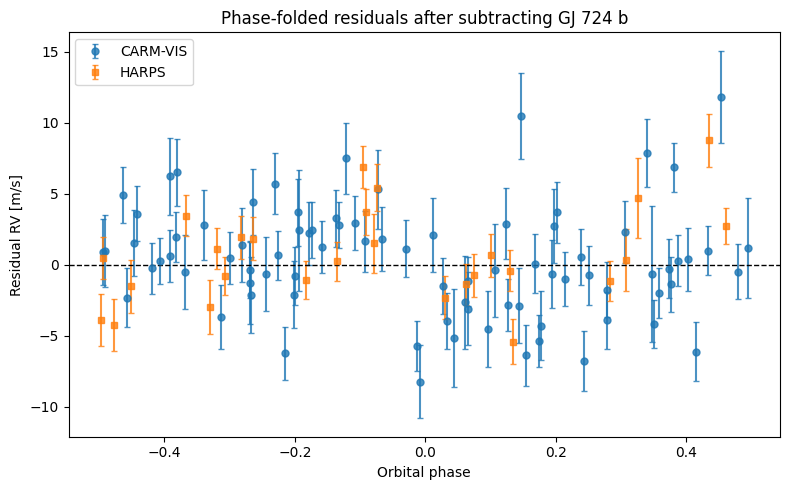

In [8]:
# Sort residuals by orbital phase for cleaner plotting
rv_residual_sorted = rv_residual[order]
rv_err_eff_sorted = rv_err_eff[order]

plt.figure(figsize=(8, 5))

plt.errorbar(
    phase_obs_sorted[m_carm_sorted],
    rv_residual_sorted[m_carm_sorted],
    yerr=rv_err_eff_sorted[m_carm_sorted],
    fmt="o", ms=5, capsize=2,
    label="CARM-VIS",
    alpha=0.8
)

plt.errorbar(
    phase_obs_sorted[m_harps_sorted],
    rv_residual_sorted[m_harps_sorted],
    yerr=rv_err_eff_sorted[m_harps_sorted],
    fmt="s", ms=5, capsize=2,
    label="HARPS",
    alpha=0.8
)

plt.axhline(0.0, color="k", ls="--", lw=1)

plt.xlabel("Orbital phase")
plt.ylabel("Residual RV [m/s]")
plt.title("Phase-folded residuals after subtracting GJ 724 b")
plt.legend()
plt.tight_layout()
plt.show()

## Define the recovery-map grid

We now define the grid of trial orbital periods and minimum masses for the recovery analysis.

A logarithmic grid is a natural choice, since detectability can vary rapidly at short periods and low masses, while a broader dynamic range is often of interest at longer periods and higher masses.

For this tutorial, we adopt a moderate grid that is large enough to be informative but still practical to run in a notebook environment.

In [9]:
# Trial grid for additional companions
period_grid = np.logspace(np.log10(1), np.log10(300.0), 50)    # days
msini_grid = np.logspace(np.log10(0.5), np.log10(30.0), 50)      # Earth masses

# Number of orbital phases tested at each grid cell
n_phase = 50

print(f"Period range: {period_grid.min():.2f} - {period_grid.max():.2f} days")
print(f"Msin(i) range: {msini_grid.min():.2f} - {msini_grid.max():.2f} M_earth")
print(f"Grid size: {len(msini_grid)} x {len(period_grid)}")
print(f"Phase samples per cell: {n_phase}")
print(f"Total number of injections: {len(msini_grid) * len(period_grid) * n_phase}")

Period range: 1.00 - 300.00 days
Msin(i) range: 0.50 - 30.00 M_earth
Grid size: 50 x 50
Phase samples per cell: 50
Total number of injections: 125000


In [10]:
# Recovery settings
criterion = "period+fap"
period_tol = 0.25
fap_alpha = 0.01

# Injection settings
phase_mode = "grid"
eccentricity_inj = 0.0
argument_periapse_inj = 90.0 * u.deg

# Periodogram settings
fap_method = "baluev"
samples_per_peak = 10
nyquist_factor = 5
search_pad_factor = 1.25

# Parallel execution
n_jobs = 32   # adjust to your machine if needed

print("Recovery settings:")
print(f"criterion         = {criterion}")
print(f"period_tol        = {period_tol:.2f}")
print(f"fap_alpha         = {fap_alpha:.3f}")
print()
print("Injection settings:")
print(f"phase_mode        = {phase_mode}")
print(f"eccentricity_inj  = {eccentricity_inj:.1f}")
print()
print("Periodogram settings:")
print(f"fap_method        = {fap_method}")
print(f"samples_per_peak  = {samples_per_peak}")
print(f"nyquist_factor    = {nyquist_factor}")
print(f"search_pad_factor = {search_pad_factor}")
print()
print(f"n_jobs            = {n_jobs}")

Recovery settings:
criterion         = period+fap
period_tol        = 0.25
fap_alpha         = 0.010

Injection settings:
phase_mode        = grid
eccentricity_inj  = 0.0

Periodogram settings:
fap_method        = baluev
samples_per_peak  = 10
nyquist_factor    = 5
search_pad_factor = 1.25

n_jobs            = 32


## Compute the recovery map on the residual RVs

We are now ready to evaluate the detectability of additional companions in the real RV dataset of GJ 724.

The recovery map is computed on the residual time series obtained after subtracting:

- the published instrument offsets,
- and the Keplerian signal of the known planet GJ 724 b.

For each point in the trial period-mass grid, RAVEX injects a synthetic signal into the residual RVs, explores multiple orbital phases, and evaluates whether the injected signal is successfully recovered according to the adopted detection criterion.

In [11]:
res_map_real = system_planet.detectability_map_from_series_parallel(
    ts=jd,
    rv=rv_residual,
    rv_err=rv_err_eff,
    period_grid=period_grid,
    msini_grid=msini_grid,
    n_phase=n_phase,
    phase_mode=phase_mode,
    eccentricity=eccentricity_inj,
    argument_periapse=argument_periapse_inj,
    criterion=criterion,
    period_tol=period_tol,
    fap_alpha=fap_alpha,
    fap_method=fap_method,
    samples_per_peak=samples_per_peak,
    nyquist_factor=nyquist_factor,
    search_pad_factor=search_pad_factor,
    rng_seed=42,
    n_jobs=n_jobs,
    verbose=True
)

print("Recovery map completed.")
print("Available output keys:")
print(sorted(res_map_real.keys()))

[detectability_map_parallel] tasks=2500, n_jobs=32, chunksize=1
Recovery map completed.
Available output keys:
['chunksize', 'criterion', 'eccentricity', 'fap_alpha', 'fap_method', 'k_tol', 'median_fap', 'median_k_relerr', 'median_p_best_days', 'median_sigma', 'mp_start_method', 'msini_grid_mearth', 'n_jobs', 'n_phase', 'nyquist_factor', 'period_grid_days', 'period_hit_rate', 'period_tol', 'phase_mode', 'recovery_rate', 'samples_per_peak', 'search_range_days']


## Visualize the recovery map

We now plot the main output of the recovery analysis: the recovery map in the orbital-period vs. minimum-mass plane.

The quantity shown is the empirical recovery fraction, which can be interpreted as a detection probability under the adopted observing setup and recovery criterion.

For reference, we also overplot the position of the known planet GJ 724 b.

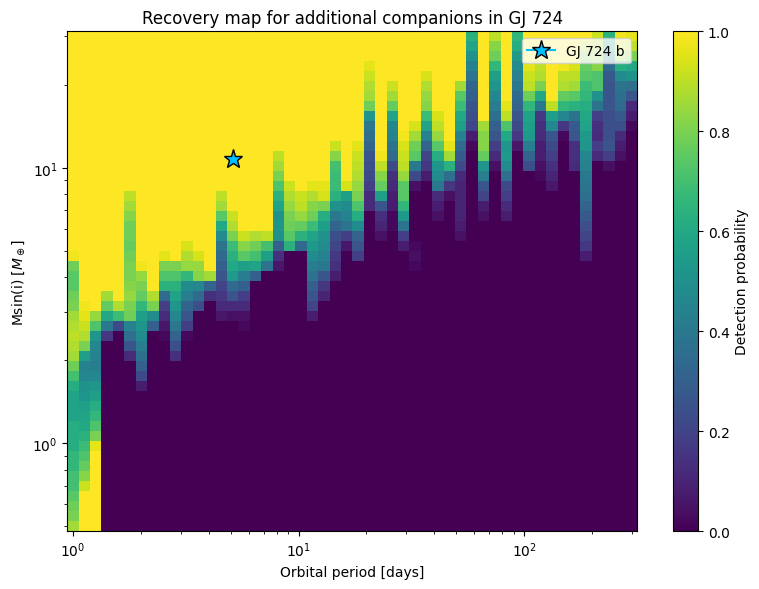

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_detectability_map(
    res_map_real,
    key="recovery_rate",
    ax=ax,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    cbar_label="Detection probability"
)

# Overplot the known planet for reference
ax.plot(
    P_b_days,
    10.75,
    marker="*",
    ms=14,
    color="deepskyblue",
    markeredgecolor="k",
    label="GJ 724 b"
)

ax.legend(loc="best")
ax.set_title("Recovery map for additional companions in GJ 724")

plt.tight_layout()
plt.show()

In [13]:
jd = df["BJD"].to_numpy(dtype=float)
rv = df["RV"].to_numpy(dtype=float)
rv_err = df["e_RV"].to_numpy(dtype=float)
inst = df["Inst"].to_numpy()

In [14]:
mass_star = 0.5271 * u.solMass

planet_gj724b = {
    "mass": 10.75 * u.earthMass,                 # M sin i ~ masa a i=90 deg
    "time_periastron": t.Time(2457509.766, format="jd", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 33.2 * u.deg,
    "eccentricity": 0.577,
    "orbital_period": 5.101284 * u.day,
    "reference_velocity": 0.0 * u.m / u.s,
}

system724 = MultiPlanetSystem(
    mass_main=mass_star,
    planets=[planet_gj724b]
)

In [15]:
f_true = system724.true_anomaly(system724.planets[0], jd)
rv_planet = system724.rv_eq(f_true, system724.planets[0])

In [16]:
gamma_by_inst = {}

for name in np.unique(inst):
    m = (inst == name)
    w = 1.0 / rv_err[m]**2
    gamma_by_inst[name] = np.sum(w * (rv[m] - rv_planet[m])) / np.sum(w)

gamma = np.array([gamma_by_inst[k] for k in inst], dtype=float)
rv_model_simple = rv_planet + gamma
rv_resid = rv - rv_model_simple

print(gamma_by_inst)
print("RMS residual [m/s]:", np.std(rv_resid, ddof=1))

{'CARM-VIS': np.float64(0.8463909153969813), 'HARPS': np.float64(-0.2042507861511896)}
RMS residual [m/s]: 3.7222269602604086


In [17]:
# =========================
# TEST PEQUEÑO EN GJ724
# =========================

period_grid_test = np.logspace(0, 2, 12)   # 1 -> 100 días
msini_grid_test  = np.logspace(np.log10(1.0), np.log10(30.0), 12)

print("Test grid:")
print("  N_periods =", len(period_grid_test))
print("  N_masses  =", len(msini_grid_test))
print("  n_phase   =", 12)
print("  total recoveries =", len(period_grid_test) * len(msini_grid_test) * 12)

t0 = time.perf_counter()
res_seq_test = system724.detectability_map_from_series(
    ts=jd,
    rv=rv_resid,
    rv_err=rv_err,
    period_grid=period_grid_test,
    msini_grid=msini_grid_test,
    n_phase=12,
    phase_mode="grid",
    eccentricity=0.0,
    criterion="period+fap",
    period_tol=0.25,
    fap_alpha=0.01,
    min_period_search=1.0,
    max_period_search=1.0e2,
    fap_method="baluev",
    rng_seed=42,
    verbose=False
)
t1 = time.perf_counter()

res_par_test = system724.detectability_map_from_series_parallel(
    ts=jd,
    rv=rv_resid,
    rv_err=rv_err,
    period_grid=period_grid_test,
    msini_grid=msini_grid_test,
    n_phase=12,
    phase_mode="grid",
    eccentricity=0.0,
    criterion="period+fap",
    period_tol=0.25,
    fap_alpha=0.01,
    min_period_search=1.0,
    max_period_search=1.0e2,
    fap_method="baluev",
    rng_seed=42,
    n_jobs=32,
    chunksize=1,
    mp_start_method="fork",
    verbose=False
)
t2 = time.perf_counter()

print(f"\nSerial test:   {t1 - t0:.3f} s")
print(f"Parallel test: {t2 - t1:.3f} s")
print(f"Speed-up test: {(t1 - t0)/(t2 - t1):.2f}x")

same_recovery = np.allclose(res_seq_test["recovery_rate"], res_par_test["recovery_rate"], equal_nan=True)
same_period   = np.allclose(res_seq_test["period_hit_rate"], res_par_test["period_hit_rate"], equal_nan=True)
same_fap      = np.allclose(res_seq_test["median_fap"], res_par_test["median_fap"], equal_nan=True)

print("\nEquality check on GJ724 test:")
print("  same recovery_rate   =", same_recovery)
print("  same period_hit_rate =", same_period)
print("  same median_fap      =", same_fap)

Test grid:
  N_periods = 12
  N_masses  = 12
  n_phase   = 12
  total recoveries = 1728


NameError: name 'time' is not defined

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for name, marker in [("CARM-VIS", "o"), ("HARPS", "s")]:
    m = (inst == name)
    axes[0].errorbar(jd[m], rv[m], yerr=rv_err[m], fmt=marker, ms=5, capsize=2, label=name)

axes[0].plot(jd[np.argsort(jd)], rv_model_simple[np.argsort(jd)], "-", lw=2, color="k", label="simple model")
axes[0].set_ylabel("RV [m/s]")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, marker in [("CARM-VIS", "o"), ("HARPS", "s")]:
    m = (inst == name)
    axes[1].errorbar(jd[m], rv_resid[m], yerr=rv_err[m], fmt=marker, ms=5, capsize=2)

axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("BJD")
axes[1].set_ylabel("Residuals [m/s]")
axes[1].grid(alpha=0.3)

plt.show()

In [ ]:
# =========================
# MAPA COMPLETO EN GJ724
# =========================

period_grid = np.logspace(0, 2, 50)   # 1 -> 100 días
msini_grid  = np.logspace(np.log10(1.0), np.log10(30.0), 50)
n_phase = 50

print("Full grid:")
print("  N_periods =", len(period_grid))
print("  N_masses  =", len(msini_grid))
print("  n_phase   =", n_phase)
print("  total recoveries =", len(period_grid) * len(msini_grid) * n_phase)

t0 = time.perf_counter()

res_map_724 = system724.detectability_map_from_series_parallel(
    ts=jd,
    rv=rv_resid,
    rv_err=rv_err,
    period_grid=period_grid,
    msini_grid=msini_grid,
    n_phase=n_phase,
    phase_mode="grid",
    eccentricity=0.0,
    criterion="period+fap",
    period_tol=0.25,
    fap_alpha=0.01,
    min_period_search=1.0,
    max_period_search=1.0e2,
    fap_method="baluev",
    rng_seed=42,
    n_jobs=32,
    chunksize=1,
    mp_start_method="fork",
    verbose=True
)

t1 = time.perf_counter()

print(f"\nTiempo total paralelo: {t1 - t0:.3f} s")

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
plot_detectability_map(
    res_map_724,
    key="recovery_rate",
    ax=ax,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    log_period=True,
    log_msini=True,
    colorbar=True,
    cbar_label="Recovery rate"
)
ax.plot(
    5.101284, 10.75,
    marker="*",
    markersize=12,
    color="dodgerblue",
    markeredgecolor="k",
    zorder=5
)
plt.show()

In [ ]:
print("GJ724 baseline [d]:", jd.max() - jd.min())
print("GJ724 Nobs:", len(jd))